# Tiled library design

Builds a pooled single-mutant library for a coding sequence longer than one synthesis oligo. The sequence is split into tiles that each fit on an oligo. Each tile gets its own orthogonal primer pair for selective amplification out of the pool, plus a Golden Gate site pair that drops it into a destination vector holding the rest of the coding sequence.

Point `tiled.starting_vector` at the plasmid you clone into and each tile's destination vector comes out as the full plasmid, ready to order or build (see the destination-plasmids section). Without one, the notebook reports the coding-region cassette for each tile instead.

Edit the input cell, then run the cells in order. Files are written to `out/`.

The layout and QC plots use matplotlib, and reading a plasmid file and writing GenBank maps use BioPython. Both come with `uv sync`. Launch with `uv run --with jupyterlab jupyter lab`.

For a short protein that fits on one oligo, use `standard-library-design.ipynb`.

## Input

The default is glucokinase, a 465-residue human gene, so the notebook runs as-is. Replace `protein` and `cds` with your own.

Set `cds` to a native coding sequence when the exact codons matter. Set `cds = None` to codon-optimize the protein into the reference instead.

In [1]:
import tomllib
from library_designer import LibrarySpec, CodonOptimizationParams, TiledAssemblyParams, SubstitutionScan

# ===== EDIT: your protein and options =====
# Default sequences come from the bundled glucokinase example. Replace with your own.
_example = tomllib.load(open("../../examples/gck_tiled.toml", "rb"))
protein = _example["protein_sequence"]   # your protein, one-letter, no stop codon
cds = _example["cds"]                     # native CDS to use verbatim; set to None to codon-optimize instead
substitutions = ["A"]                     # ["A"] alanine scan; list("ACDEFGHIKLMNPQRSTVWY") for full DMS

spec = LibrarySpec(
    name="GCK_tiled_library",
    protein_sequence=protein,
    cds=cds,
    substitutions=substitutions,
    optimization=CodonOptimizationParams(species="e_coli"),   # picks the mutant codon; also builds the reference when cds is None
    tiled=TiledAssemblyParams(
        oligo_budget=300,                 # your synthesis oligo length
        enzyme="BsaI",                    # Golden Gate enzyme
        primer_set="subramanian2018",     # bundled orthogonal set, or a path to your own CSV
        optimize_overhangs=True,          # move the boundaries to the least similar overhangs (default off)
        pad_oligos=True,                  # pad every oligo to one length (default off)
        # screen_primers=True,            # skip primers that would prime elsewhere in the pool
    ),
    platform="twist_oligo_pools",
)
spec

name,GCK_tiled_library
protein,465 aa MLDDRARMEAAK...AVACKKACMLGQ
substitutions,A
adaptors,5' 3'
starting_vector,not set
avoid,BsaI + 2 motif pattern(s)
optimization,"e_coli, use_best_codon"
platform,twist_oligo_pools
max_oligo_length,not set
gc_bounds,not set
seed,0


## Build and tile

`codon_optimize()` fixes one reference sequence and stamps each mutant onto it. `tile()` splits the reference into oligo-sized windows on codon boundaries, assigns each variant to its window, picks a primer pair per tile, and assembles the final oligo. Per-tile primers and destination vectors are stored on `lib.tiles`. Each `vector` is the coding-region cassette, or the full destination plasmid when `tiled.starting_vector` is set.

`tile()` also adds one wild-type member per tile, `WT_Tile_0` and so on, each carrying that tile's window straight from the reference. A tile is amplified and assembled on its own, so it needs its own unmutated clone to sequence and normalize against. The single `WT` row stays in the table for the record and rides on no oligo. Set `tiled.wt_controls = False` to order only the mutants.

In [2]:
lib = SubstitutionScan(spec).generate().codon_optimize().tile()
print(len(lib), "members across", len(lib.tiles), "tiles",
      f"({int(lib.df['mut_index'].notna().sum())} mutants, one WT control per tile)")
if lib.failed:
    print(len(lib.failed), "could not be built:", lib.failed)

444 members across 6 tiles (437 mutants, one WT control per tile)
1 could not be built: {'Y273A': 'any synonymous codon for A at position 273 introduces a restricted motif'}


## Tile layout

Each tile is a bar over the region of the coding sequence it covers, labelled with its variant count and primer pair. The top track shows where the mutations fall.

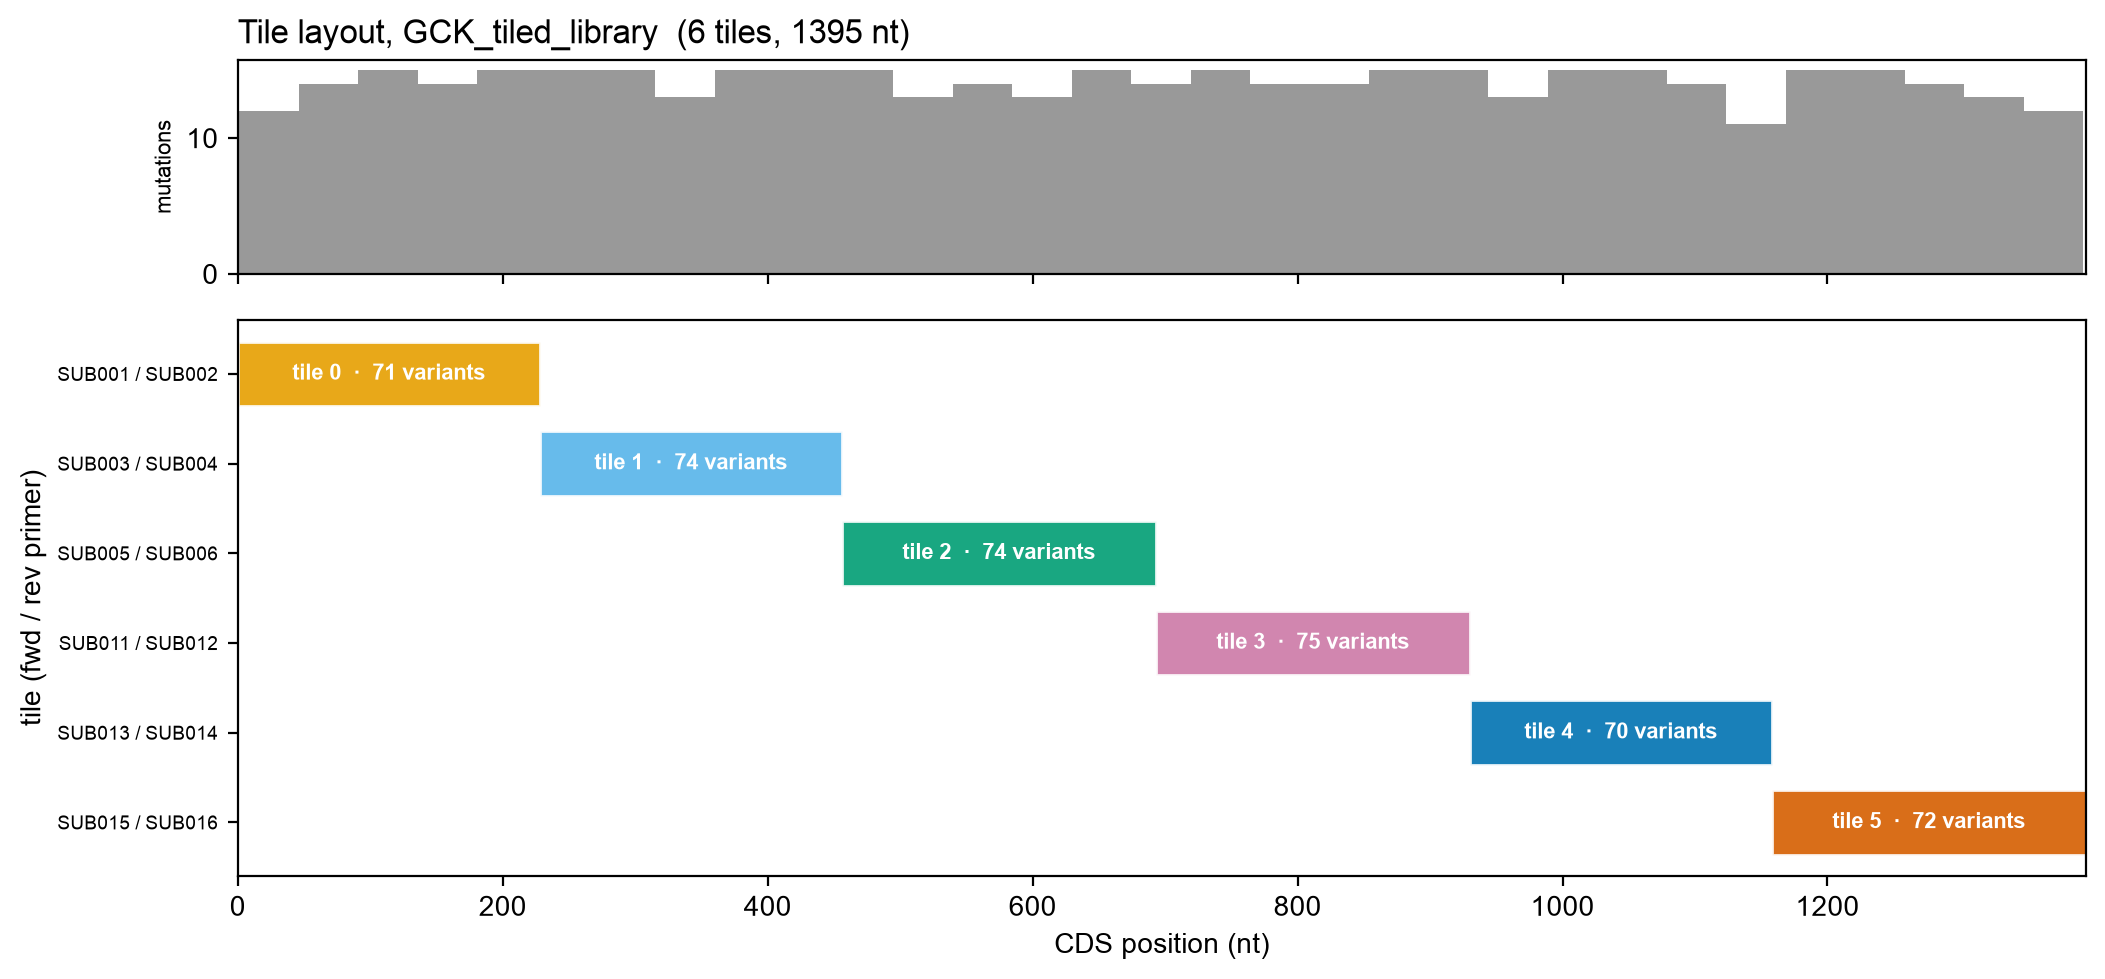

In [3]:
lib.plot_tiling()

## Tiles

One row per tile: the window on the coding sequence, the primer pair that amplifies it, its two fused overhangs, and the length of its destination vector.

`pad_5` and `pad_3` are the filler that brings each oligo up to the pool's common length, so `oligo_nt` is the same on every row. Tiles differ in size, and the boundary search below widens that spread, so without padding the pool would hold several oligo lengths. The filler sits outside both Golden Gate sites, which means it is amplified with the oligo and then cut away. Nothing padded reaches the assembled plasmid.

In [4]:
import pandas as pd
from library_designer.layout.tiled import tile_contexts

pd.DataFrame([{
    "tile": t.index, "start": t.start, "end": t.end, "tile_nt": t.end - t.start,
    "forward": f"{t.fwd_id}: {t.fwd}", "reverse": f"{t.rev_id}: {t.rev}",
    "overhangs": " / ".join(tile_contexts(lib.reference, t.start, t.end, lib.tiled_params)),
    "pad_5": len(t.pad_5), "pad_3": len(t.pad_3),
    "oligo_nt": int(lib.df.loc[lib.df["tile"] == t.index, "oligo_length"].max()),
    "vector_nt": len(t.vector),
} for t in lib.tiles])

,tile,start,end,tile_nt,forward,reverse,overhangs,pad_5,pad_3,oligo_nt,vector_nt
0,0,0,228,228,SUB001: AAACACGTGGCAAACATTCC,SUB002: AAACCGGAGCCATACAGTAC,TGGA / CTGG,5,4,299,1185
1,1,228,456,228,SUB003: AAAGCACTCTTAGGCCTCTG,SUB004: AAAGGGGCCGTCAATATCAG,CTCC / CCTG,5,4,299,1185
2,2,456,693,237,SUB005: AAATAAGACGACGACCCTCG,SUB006: AACGATGATGCTCACTCTCG,CTTT / GCCT,0,0,299,1176
3,3,693,930,237,SUB011: AAGAATTACTGACCCCTCGG,SUB012: AAGACGATCCGAGCCATTAC,CAAT / GACG,0,0,299,1176
4,4,930,1158,228,SUB013: AAGGAACTATGGCATCGAGC,SUB014: AAGGACTGCATACCAGGTTG,CGTG / GCGG,5,4,299,1185
5,5,1158,1395,237,SUB015: AAGGATATGTAGACACCGCC,SUB016: AAGGCCCAGAAGGATACAAC,GCTG / GGAG,0,0,299,1176


## Overhangs

Worth reviewing before you order anything. Each tile is dropped in by a pair of four-base Golden Gate overhangs, and the reaction is only directional if those two tell each other apart. Overhangs that are too alike give you two bad outcomes. The cut vector's own ends can anneal to each other and it re-closes empty, which is a unimolecular reaction and so a strong background of parent plasmid. Or the fragment anneals the other way round and goes in backwards.

**The unit here is one tile.** Each tile is amplified out of the pool with its own primer pair and assembled into the vector built around its own window, so its reaction holds its own fragments and nothing else. Tile 0's overhangs and tile 3's never meet, and they cannot be pooled either, since every tile needs the particular vector that drops out its own window. So the comparisons that mean anything are a tile's two ends against each other, and each end against its own reverse complement.

These overhangs are not chosen from an orthogonal set. They are read off the coding sequence at each tile boundary, so a boundary is the only handle on them. `tiled.optimize_overhangs`, set in the input cell, is what uses that handle: the oligo budget caps a tile but the balanced split sits under the cap, so there are spare codons and every one of them is a boundary that could move. The search tries those positions and keeps the layout whose overhangs share the least sequence. It never returns a layout worse than the balanced split, since the split is scored alongside every candidate.

The matrix below is every overhang against every other. A cell is how many of the four bases the two share, taking the worse of the two orientations: as written, which is how a vector re-closes, and against the reverse complement, which is how a fragment flips. Aim for at most one shared base.

Only the cells that can misfire are graded. Those are the boxed ones, a tile's own two ends, and the diagonal, an overhang against its own reverse complement, where a hot cell means a palindrome and copies of the fragment can concatemerize. Cross-tile cells are faded: the count is there if you want it, but those tiles are assembled in separate tubes.

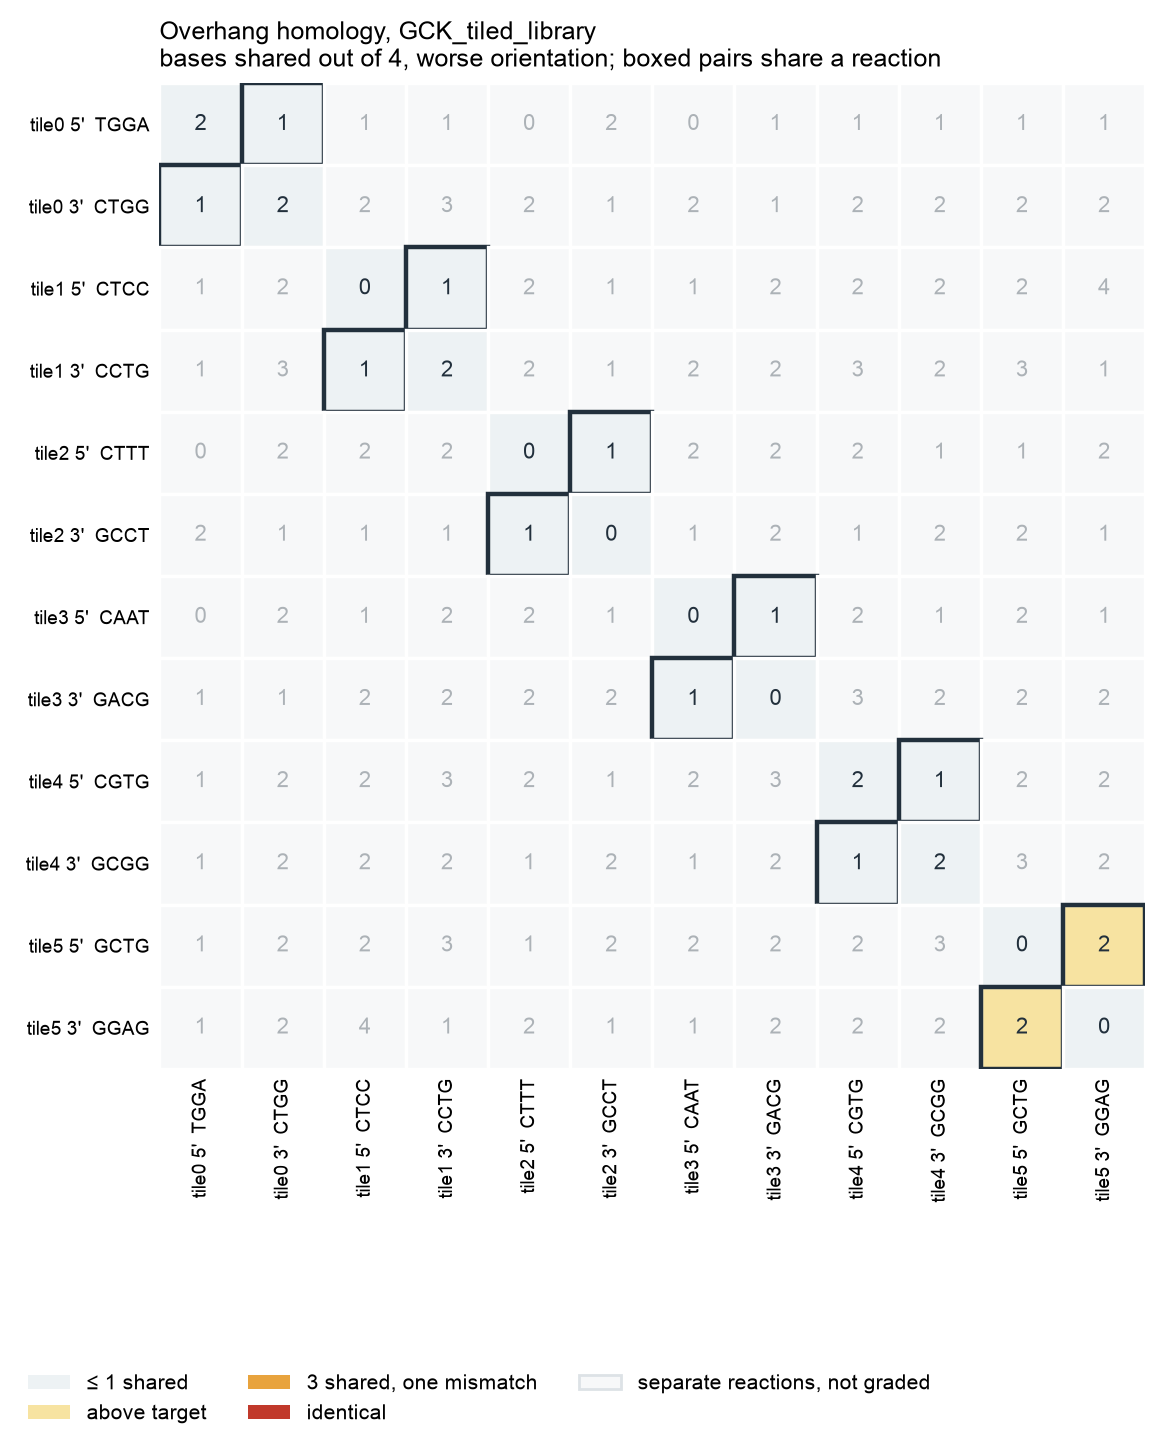

In [5]:
lib.plot_overhangs()

The same numbers as a table, one row per tile, worst first. `shared` is the bases the tile's two ends have in common as written and `shared_flipped` the bases against the reverse complement. This is the table to read before ordering.

Pass `all_pairs=True` to list the cross-tile pairs too. They come back with their counts and a `risk` of `n/a`, since those tiles never share a tube. `lib.overhangs()` lists the individual overhangs with their sequences.

In [6]:
pairs = lib.overhang_pairs()          # one row per tile; all_pairs=True adds the cross-tile rows
print(pairs["risk"].value_counts().to_dict())
pairs

{'ok': 5, 'watch': 1}


,end_a,overhang_a,end_b,overhang_b,same_reaction,shared,shared_flipped,risk,note
0,tile5 5',GCTG,tile5 3',GGAG,True,2,0,watch,"tile5: the two ends (GCTG, GGAG) share 2 of 4 ..."
1,tile0 5',TGGA,tile0 3',CTGG,True,1,0,ok,
2,tile1 5',CTCC,tile1 3',CCTG,True,1,1,ok,
3,tile2 5',CTTT,tile2 3',GCCT,True,1,0,ok,
4,tile3 5',CAAT,tile3 3',GACG,True,1,1,ok,
5,tile4 5',CGTG,tile4 3',GCGG,True,1,1,ok,


### What the search bought

The two layouts side by side, the balanced split against the boundaries the search picked, counting only the comparisons that can misfire. Glucokinase is a good case for it: the even split leaves tile4 with two ends one mismatch from complementary, so that fragment could ligate in backwards.

Set `optimize_overhangs=False` in the input cell and re-run to see the layout without it.

In [7]:
from library_designer.checks.overhangs import risk_of, self_risk, shared_bases
from library_designer.layout.boundaries import layout_ends
from library_designer.layout.tiled import compute_tiles
from library_designer.regions import reverse_complement

params = lib.tiled_params
layouts = {
    "balanced split": compute_tiles(len(lib.reference), params),
    "after the search": [(t.start, t.end) for t in lib.tiles],
}
for label, windows in layouts.items():
    ends = layout_ends(lib.reference, params, windows)
    tally = {"collision": 0, "high": 0, "watch": 0}
    for i, (tile_a, a) in enumerate(ends):
        if self_risk(shared_bases(a, reverse_complement(a)), len(a)) == "collision":
            tally["collision"] += 1                        # palindromic
        for tile_b, b in ends[i + 1:]:
            if tile_a != tile_b:
                continue                                   # separate tubes, they never meet
            worst = max(shared_bases(a, b), shared_bases(a, reverse_complement(b)))
            tally[risk_of(worst, len(a))] = tally.get(risk_of(worst, len(a)), 0) + 1
    print(f"{label:>16}: {' '.join(s for _, s in ends)}")
    print(f"{'':>16}  tiles {[e - s for s, e in windows]}")
    print(f"{'':>16}  per reaction: {tally['collision']} unusable, "
          f"{tally['high']} at one mismatch, {tally['watch']} above target")

  balanced split: TGGA CTGG GGAC GAAG GCAC ATGG CTAC GAAA GGAC GTCA GGGC GGAG
                  tiles [234, 234, 234, 231, 231, 231]
                  per reaction: 0 unusable, 1 at one mismatch, 4 above target
after the search: TGGA CTGG CTCC CCTG CTTT GCCT CAAT GACG CGTG GCGG GCTG GGAG
                  tiles [228, 228, 237, 237, 228, 237]
                  per reaction: 0 unusable, 0 at one mismatch, 1 above target


## Primer specificity

Each tile's sublibrary comes out of the shared pool on its own primer pair, so a primer has to bind in one place. The set it was drawn from is orthogonal to the other primers in it, which says nothing about your coding sequence or your backbone. If a primer's 3' end also anneals inside a variable region, inside another tile's flank, or in the plasmid, the polymerase extends from there too and you get a product the design does not account for.

`lib.mispriming()` scores every primer on the longest duplex reaching back from its 3' end, the end extension starts at, that it could form somewhere it should not. Both strands are searched, since a primer anneals to whichever strand carries the sequence. A duplex as long as the whole primer is a second binding site and fails the report. A shorter one is reported and left to you, because whether 14 of 20 bases prime depends on the annealing temperature you run at.

A duplex may carry one internal mismatch. Reading exact runs alone would take a primer whose last five bases pair, then one mismatches, then fourteen more pair, and score it as five bases, when it is a 19-of-20 duplex that primes readily. The last three bases have to pair whatever the budget is, since a mismatch at or beside the 3' base leaves nothing for the polymerase to extend from. `paired` is how many bases pair, `aligned` how long the duplex is, and `mismatches` how many bases inside it do not, so a clean run has `paired` equal to `aligned`. Pass `mismatches=0` for exact runs only, or 2 to look harder. A mismatched duplex is always an advisory, never a failure.

Every member is the reference with one codon swapped, so the variable region is checked as the reference plus a window around each member's own codon. A member's own duplex counts only when it covers that codon and pairs more bases than the same duplex pairs on the WT, so a site the reference already has is reported once against the reference rather than once for every member that shares the neighbourhood.

Pass `extra=["..."]` to score a primer the library does not carry, a nested primer or the outer handle on a stock pool. Setting `screen_primers=True` in the input cell makes the tiler pass over any primer that would prime on the coding sequence, on the backbone, or on a primer it already drew, so the pool comes out clean instead of being reported on afterwards.

In [8]:
sites = lib.mispriming()          # extra=["ACGT..."] to score a primer of your own
print(sites["risk"].value_counts().to_dict() or "no priming sites to report")
sites

{'watch': 1}


,handle,handle_seq,region,kind,where,position,strand,paired,aligned,mismatches,matched,risk,note
0,tile5 fwd,AAGGATATGTAGACACCGCC,variant codons,variable,S373A,18,-,12,12,0,GTAGACACCGCC,watch,tile5 fwd has its last 12 bases (GTAGACACCGCC)...


## Check

Along with the standard checks, QC confirms each oligo carries exactly the two intended Golden Gate sites (a site formed where a primer meets the insert fails here) and stays within the oligo budget. It scores the overhangs from the section above too, comparing only the ends that share a reaction. A tile whose two ends are identical, complementary, or palindromic fails the report, because then the wrong product is the expected one. A single mismatch is an advisory, since the overhangs come off the coding sequence and the fix is to move a boundary, not to pick different bases.

It then simulates the assembly: cut each oligo, cut its destination vector, ligate, and check that the product carries that variant's coding sequence. With a starting vector set it also aligns each product against the parent plasmid, so the report says outright whether every clone differs from the plasmid you started with at one codon and no more.

In [9]:
print(lib.check())

QC report: 444 variants, FAIL
  optimization:        1 failed (Y273A)
  translation:         443/443
  forbidden sequences: none (checked BsaI, 2 motifs)
  assembly:            442/442 rebuild their variant
  advisories:          4, not failures
    - reference carries 3 /GGAGG.{8,12}[AG]TG/ motif(s), kept verbatim (not recoded)
    - reference carries 1 /AGGAG.{8,12}ATG/ motif(s), kept verbatim (not recoded)
    - 1 reaction has two ends sharing more than 1 base without being a near match; see lib.overhang_pairs()
    - 1 shorter duplex pairing 12-14 bases where they should not, too few to prime on their own at a normal annealing temperature; see lib.mispriming()


## Codon-usage QC

Relative codon adaptiveness along the coding sequence. The grey line is the wild-type backbone; each point is a variant's stamped codon, coloured by sublibrary. Lower points are synonymous codons chosen to avoid a motif.

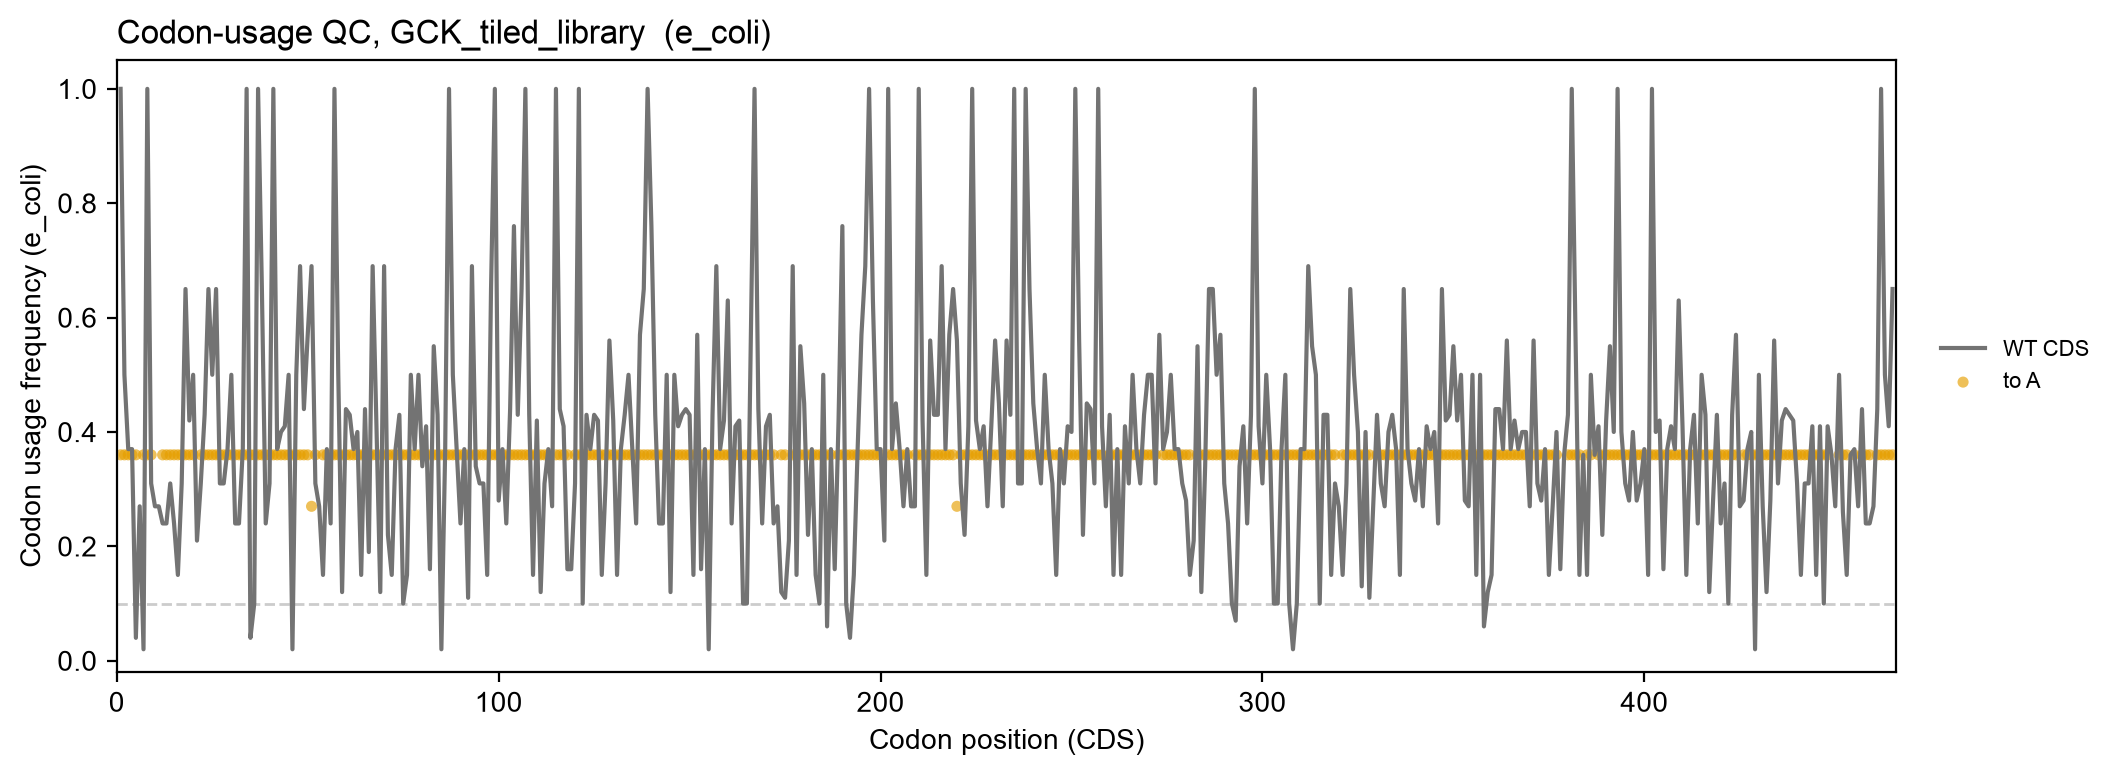

In [10]:
lib.plot_codon_usage()

## Export

Drops any variant that failed to build, then writes the order, cloning, and QC files. `lib.run_dir("out")` gives this run its own dated directory, so a re-run cannot overwrite an order you already sent and every file can be traced back to the run that made it.

`to_vectors` writes a one-row-per-tile manifest of destination-vector sequences. With a starting vector set, `to_vector_maps` also writes an annotated GenBank plasmid per tile (see the next section).

In [11]:
if lib.failed:
    lib.drop_failed()

out = lib.run_dir("out")                   # out/<name>_<date>_<time>: this run's own directory

lib.to_oligo_pool(out / "oligos.csv")      # pooled synthesis order, one row per oligo (incl. the WT controls)
lib.to_primer_order(out / "primers.csv")   # per-tile amplification primers, IDT bulk-order format
lib.to_vectors(out / "vectors.csv")        # per-tile destination-vector sequences (manifest)
lib.to_full_csv(out / "library_full.csv")  # every variant with tile, oligo, and QC columns
lib.to_qc_plots(out / "codon_usage.png")   # codon-usage QC figure
lib.to_design_specs(out / f"{lib.spec.name}_design_specs.json")   # spec, reference, primer set, tool versions

import os
print("wrote to", out)
for f in sorted(os.listdir(out)):
    print("  ", f)

wrote to out/GCK_tiled_library_20260806_122914
   GCK_tiled_library_design_specs.json
   codon_usage.png
   library_full.csv
   oligos.csv
   primers.csv
   vectors.csv


## Destination plasmids

The steps above emit each tile's destination vector as a bare coding-region cassette, because no backbone was given. To get the real plasmids you clone into, point `starting_vector` at your destination plasmid (`.gb`, `.dna`, or `.fasta`). The WT CDS is located inside it (on either strand), and each tile's vector comes out as the full plasmid with that tile's window replaced by the drop-out.

```python
spec.starting_vector = "my_destination.gb"
# optional: freeze the CDS already in the plasmid and clone the vectors straight from it,
# which flags SD sites and motifs in that CDS rather than recoding them
spec.starting_vector.use_vector_cds = True
# optional: name the insert feature when the plasmid holds more than one CDS
spec.starting_vector.insert_label = "my_gene"

lib = SubstitutionScan(spec).generate().codon_optimize().tile()
lib.to_vector_maps(lib.run_dir("out") / "vectors")   # one annotated GenBank per tile, plus a manifest
```

Each map is the full plasmid with that tile's window swapped for the BsaI drop-out, annotated with the enzyme sites, fused overhangs, retained CDS arms, and your backbone's own features. The whole plasmid is screened for stray BsaI sites that would misdirect assembly.

## Notes

- The default primer set (`subramanian2018`) has 164 screened primers, enough for about 82 tiles. To use your own, set `tiled.primer_set` to a CSV path (a pool with a `sequence` column, or explicit `forward` and `reverse` columns). A sequence that needs more tiles than the set provides raises an error.
- A position where every synonymous codon would introduce a restricted motif is reported in `lib.failed` and left out of the oligo order.
- `oligo_budget` is the synthesis oligo length. `enzyme` selects the Golden Gate enzyme, `BsaI` by default.
- `optimize_overhangs` and `pad_oligos` are both off by default, so an existing design keeps the boundaries and oligos it already had. Turning the search on moves the boundaries, which changes every oligo, so re-order the whole pool rather than mixing the two layouts.
- `pad_target` sets the padded length outright. Left unset, the pool is evened up to the longest oligo the layout already needed, so no oligo grows past that. A target over `oligo_budget` is refused.
- `screen_primers` is off by default too. Turning it on makes the tiler skip any primer whose 3' end would anneal to the coding sequence, to the backbone, or to a primer it already drew, which changes the primers a design draws and so the oligos it emits. QC reports those sites either way; see the primer-specificity section.
